# 1. Análise Exploratória (EDA): Características dos Change Points
Esta etapa valida as *features* extraídas dos eventos de rede antes da classificação pelo GMM.

## 1.1 Parametrização e Contexto
A análise fundamenta-se na identificação de **transições de estado** na rede. Cada registro representa um ponto de mudança (*Change Point*) que delimita a fronteira estatística entre dois regimes operacionais distintos.

* **Cenário:** Dataset bruto processado. Representa a origem dos dados e o intervalo temporal utilizado para a extração dos eventos.
* **Métrica de Referência:** Métrica escolhida como gatilho para a segmentação. Determina qual variável de rede foi monitorada pelo algoritmo para identificar as quebras de regime estatístico.
* **Limiar (Threshold):** Valor crítico da probabilidade de cauda. Define a sensibilidade do algoritmo e o rigor estatístico necessário para validar uma mudança de estado.

In [40]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# --- Configurações de Aparência ---
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# --- Parâmetros do Estudo ---
SCENARIO = "NDT_NOV_ABR"
METHOD = "vwcd"
REF_METRIC = "rtt_down"
THRESHOLD = 0.95

# --- Caminho do Arquivo de Features ---
base_path = os.path.join("features", SCENARIO)
file_name = f"features_{METHOD}_{REF_METRIC}_{THRESHOLD}.csv"
full_path = os.path.join(base_path, file_name)

# --- Carregamento ---
if os.path.exists(full_path):
    # O df_ana aqui já contém os eventos (Change Points) com seus respectivos deltas
    df_ana = pd.read_csv(full_path)
    
    print(f"Dataset carregado com sucesso!")
else:
    print(f"Erro: O arquivo {full_path} não foi encontrado.")

# --- PRÉ-PROCESSAMENTO: Clipping ---
cols_to_clip = ['d_rtt_down', 'd_rtt_up', 'd_tp_down', 'd_tp_up', 'd_pl']

# Aplicação do Clipping nos percentis 1% e 99% (NÃO UTILIZADO)
# for col in cols_to_clip:
#     if col in df_ana.columns:
#         lower_bound = df_ana[col].quantile(0.01)
#         upper_bound = df_ana[col].quantile(0.99)
#         # Substitui os valores extremos pelos próprios limites dos percentis
#         df_ana[col] = df_ana[col].clip(lower=lower_bound, upper=upper_bound)
        
# print("Pré-processamento estatístico aplicado: Outliers limitados.")

Dataset carregado com sucesso!


## 1.2 Caracterização Geral do Dataset

Esta etapa quantifica o volume de dados e a diversidade de dispositivos no período analisado para garantir que a base suporta o uso do GMM.

### Justificativa Técnica para o uso do GMM

A base de dados deve atender a dois requisitos para que os resultados do modelo sejam confiáveis:

* **Diversidade de Pares:** O envolvimento de múltiplos clientes e servidores evita que o modelo aprenda vícios de uma única rota, focando em comportamentos gerais da rede.
* **Volume de Eventos:** É necessário um número total de eventos significativamente superior ao número de variáveis do modelo para garantir estabilidade no cálculo das médias e correlações.

Esta análise confirma se há dados suficientes para separar os problemas de rede (como Congestionamento e Mudança de Rota) conforme as assinaturas da literatura. 

In [41]:
# --- Cálculo de Métricas de Caracterização ---

# Extração da Janela Temporal
df_ana['timestamp'] = pd.to_datetime(df_ana['timestamp'])
data_inicio = df_ana['timestamp'].min().strftime('%m/%Y')
data_fim = df_ana['timestamp'].max().strftime('%m/%Y')

# Identificação das entidades únicas no dataset
total_clients = df_ana['client'].nunique()
total_servers = df_ana['server'].nunique()
total_pairs = df_ana.groupby(['client', 'server']).ngroups
total_events = len(df_ana)

# Cálculo da densidade de eventos por conexão
avg_cp_per_pair = total_events / total_pairs if total_pairs > 0 else 0

# Exibição do Relatório de Viabilidade
print(f"{'='*50}")
print(f" RELATÓRIO DE CARACTERIZAÇÃO DO CENÁRIO: {SCENARIO}")
print(f"{'='*50}")
print(f"Período de Análise:                 {data_inicio} até {data_fim}")
print(f"Limiar de Detecção:                 {THRESHOLD}")
print(f"Total de Clientes únicos:           {total_clients}")
print(f"Total de Servidores únicos:         {total_servers}")
print(f"Total de Pares Cliente-Servidor:    {total_pairs}")
print(f"Total de Eventos (Change Points):   {total_events}")
print(f"Média de eventos por par:           {avg_cp_per_pair:.2f}")
print(f"{'='*50}")

# Verificação qualitativa para o GMM
# if total_events > 100:
#     print("Status: Volume de dados satisfatório para convergência do GMM.")
# else:
#     print("Aviso: Volume de dados reduzido. Os clusters podem apresentar baixa estabilidade.")

 RELATÓRIO DE CARACTERIZAÇÃO DO CENÁRIO: NDT_NOV_ABR
Período de Análise:                 11/2025 até 04/2026
Limiar de Detecção:                 0.95
Total de Clientes únicos:           16
Total de Servidores únicos:         9
Total de Pares Cliente-Servidor:    72
Total de Eventos (Change Points):   869
Média de eventos por par:           12.07


## 1.3 Análise de Sincronização e Distribuição das Variações

Esta seção avalia a coordenação entre os eventos e a magnitude das mudanças detectadas. Primeiro, utiliza-se o **Synchronization Score ($S_{e}$)**, que quantifica a fração de métricas com mudança simultânea no mesmo instante. Para as 5 métricas monitoradas ($|\mathcal{M}|=5$), o score varia de 0,2 (mudança isolada) a 1,0 (todas as métricas alteradas). Em seguida, analisam-se os **Deltas**, que capturam a variação de desempenho entre regimes conforme a tabela abaixo:

| Métrica | Tipo de Variação | Cálculo do Delta | Unidade |
| :--- | :--- | :--- | :--- |
| **RTT** (Up/Down) | Absoluta | Mediana(Post) - Mediana(Ant) | ms |
| **TP** (Up/Down) | Relativa | [Mediana(Post) - Mediana(Ant)] / Mediana(Ant) | taxa |
| **PL** | Absoluta | Média(Post) - Média(Ant) | % |

### Interpretação Técnica e Justificativa para o GMM

A distribuição tanto dos scores de sincronização quanto das magnitudes de variação define a viabilidade da clusterização multivariada:

* **Assinaturas de Rede:** O $S_{e}$ orienta a formação dos clusters. Espera-se que o **Congestionamento** apresente alta sincronização ($S_{e} \to 1$) por afetar atraso, vazão e perda simultaneamente. Já as **Mudanças de Rota** ou ruídos tendem a apresentar sincronização moderada ou baixa ($S_{e} \approx 0,2$ a $0,4$).
* **Escalonamento e Estabilidade:** A análise dos deltas verifica se as ordens de grandeza das métricas permitem que o modelo calcule as matrizes de covariância sem erros numéricos. O uso da mediana para RTT e TP ajuda a estabilizar o modelo contra picos transientes.
* **Impacto de Outliers e Multimodalidade:** Identifica-se se as caudas das distribuições representam anomalias reais ou ruído e se as variações sugerem grupos distintos de dados. Se a predominância for de scores baixos e variações mínimas, a capacidade do GMM de separar componentes robustos diminui.

O objetivo final é confirmar se o volume de eventos sincronizados e as magnitudes observadas são suficientes para distinguir as assinaturas de rede (Congestionamento vs. Rota) conforme descrito no referencial teórico.

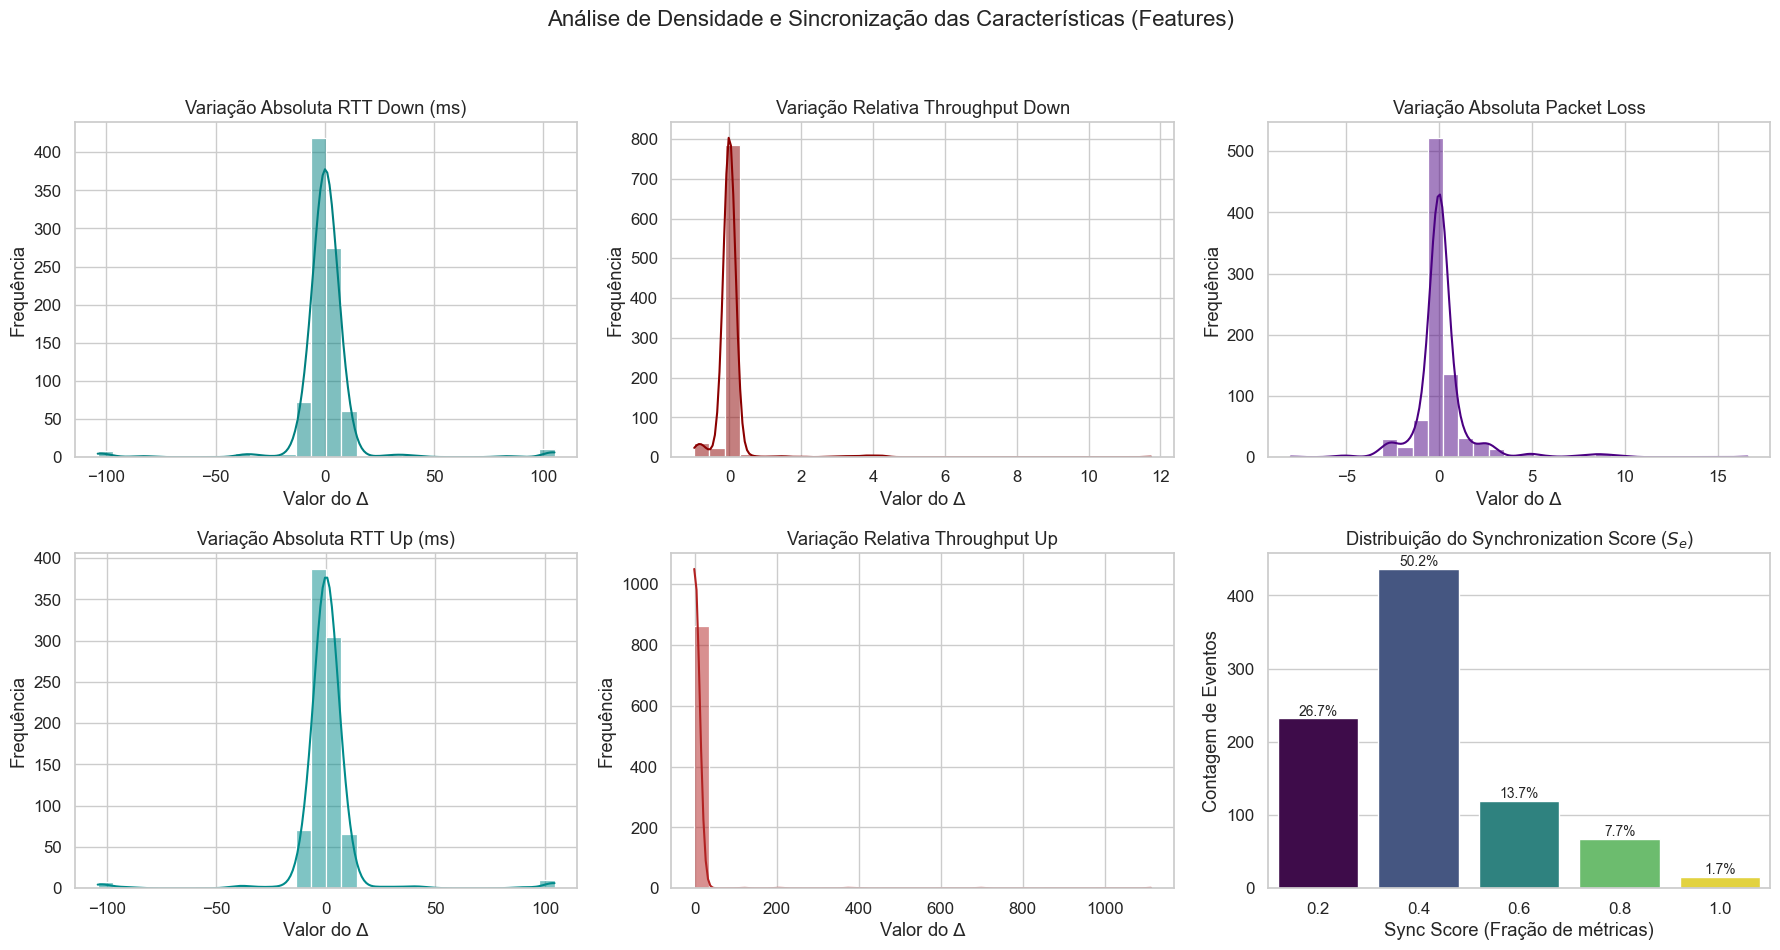

ESTATÍSTICAS DESCRITIVAS DAS FEATURES
       d_rtt_down  d_tp_down      d_pl  d_rtt_up    d_tp_up
count    869.0000   869.0000  869.0000  869.0000   869.0000
mean       0.3784     0.0378    0.1792    0.3774     2.9384
std       17.1690     0.6272    1.6743   17.3166    46.8946
min     -104.0000    -0.9804   -7.9810 -104.0780    -0.9991
25%       -2.1350    -0.0103   -0.1769   -2.1395    -0.0348
50%        0.0000    -0.0001    0.0051    0.0180    -0.0004
75%        3.0000     0.0085    0.2635    2.7795     0.0271
max      105.0570    11.7377   16.6123  104.3790  1112.9329

Distribuição percentual dos Sync Scores ($S_{e}$):
sync_score
0.2    26.70
0.4    50.17
0.6    13.69
0.8     7.71
1.0     1.73
Name: proportion, dtype: float64


In [42]:
# --- Análise de Sincronização e Distribuições de Variação (Deltas) ---

# Seleção das métricas e configurações de plotagem
metrics_to_plot = [
    ('d_rtt_down', 'Variação Absoluta RTT Down (ms)', 'teal'),
    ('d_tp_down', 'Variação Relativa Throughput Down', 'darkred'),
    ('d_pl', 'Variação Absoluta Packet Loss', 'indigo'),
    ('d_rtt_up', 'Variação Absoluta RTT Up (ms)', 'darkcyan'),
    ('d_tp_up', 'Variação Relativa Throughput Up', 'firebrick')
]

# Criação da figura 2x3 para consolidar todas as análises
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.suptitle("Análise de Densidade e Sincronização das Características (Features)", fontsize=16)
axes_flat = axes.flatten()

# 1. Plotagem dos Histogramas com KDE para os Deltas (Primeiras 5 posições)
for i, (col, label, color) in enumerate(metrics_to_plot):
    if col in df_ana.columns:
        sns.histplot(df_ana[col], kde=True, color=color, ax=axes_flat[i], bins=30)
        axes_flat[i].set_title(label)
        axes_flat[i].set_xlabel("Valor do $\\Delta$")
        axes_flat[i].set_ylabel("Frequência")

# 2. Plotagem do Synchronization Score (S_e) na sexta posição
ax_sync = axes_flat[5]
sns.countplot(data=df_ana, x='sync_score', hue='sync_score', palette='viridis', ax=ax_sync, legend=False)

ax_sync.set_title("Distribuição do Synchronization Score ($S_{e}$)")
ax_sync.set_xlabel("Sync Score (Fração de métricas)")
ax_sync.set_ylabel("Contagem de Eventos")

# Adição de labels de porcentagem sobre as barras do Sync Score
total = len(df_ana)
for p in ax_sync.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{100 * height / total:.1f}%'
        ax_sync.annotate(percentage, (p.get_x() + p.get_width() / 2, height), 
                         ha='center', va='bottom', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Resumo Estatístico para o Relatório ---
print(f"{'='*50}")
print("ESTATÍSTICAS DESCRITIVAS DAS FEATURES")
print(f"{'='*50}")
print(df_ana[[m[0] for m in metrics_to_plot]].describe().round(4))
print("\nDistribuição percentual dos Sync Scores ($S_{e}$):")
print((df_ana['sync_score'].value_counts(normalize=True).sort_index() * 100).round(2))

## 1.4. Matriz de Correlação Global

A Matriz de Correlação é uma importante ferramenta para validar a viabilidade de um Modelo de Mistura Gaussiana (GMM). Ela quantifica a dependência linear entre as características extraídas.

### Justificativa Técnica e GMM

* **Estrutura de Covariância**: O GMM estima uma matriz de covariância para cada componente. Se as métricas forem totalmente independentes (correlação próxima de zero), os clusters serão esferas alinhadas aos eixos. Se houver correlação, os clusters serão elipsoides inclinados, capturando melhor a dinâmica real da rede.
* **Consistência Teórica**: De acordo com a Seção 4 do referencial, esperamos correlações negativas entre atraso e vazão em cenários de congestionamento.
* **Redundância**: Ajuda a identificar se métricas de Upload e Download respondem de forma simétrica ou independente às mudanças de regime.

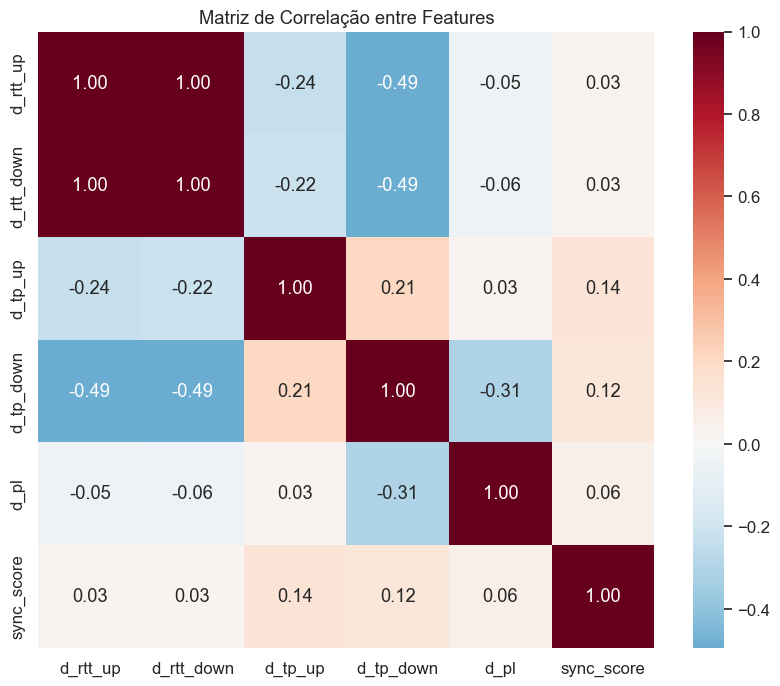

Correlação RTT Down vs TP Down: -0.4899
Correlação RTT Up vs TP Up:     -0.2391


In [43]:
# --- Matriz de Correlação Global ---

plt.figure(figsize=(10, 8))
corr_cols = ['d_rtt_up', 'd_rtt_down', 'd_tp_up', 'd_tp_down', 'd_pl', 'sync_score']
correlation_matrix = df_ana[corr_cols].corr()

# Mapa de calor para identificar dependências multivariadas
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", square=True)

plt.title("Matriz de Correlação entre Features")
plt.show()

# Verificação de simetria Up/Down
print(f"Correlação RTT Down vs TP Down: {correlation_matrix.loc['d_rtt_down', 'd_tp_down']:.4f}")
print(f"Correlação RTT Up vs TP Up:     {correlation_matrix.loc['d_rtt_up', 'd_tp_up']:.4f}")

## 1.5 Avaliação de Outliers e Dispersão (Boxplots)

Esta seção utiliza diagramas de caixa para identificar visualmente pontos extremos e a dispersão das variações. Devido às diferentes escalas (ms, taxas e %), cada métrica é analisada individualmente para evitar distorções de visualização.

### Justificativa Técnica para um possível Pré-Processamento

A identificação de outliers é fundamental para garantir a estabilidade do modelo:

* **Sensibilidade do GMM:** Como o algoritmo baseia-se no cálculo de médias ($\mu$) e matrizes de covariância ($\Sigma$), valores extremos podem deslocar os centroides e distorcer a geometria dos componentes, dificultando a separação clara entre os clusters.
* **Critérios de Tratamento:** A análise dos limites interquartis (IQR) fornece o embasamento empírico necessário para avaliar estratégias de tratamento de dados atípicos, garantindo que a entrada do modelo reflita comportamentos representativos da rede.
* **Assimetria e Direcionalidade:** O posicionamento dos outliers revela se as variações extremas seguem uma tendência física específica, ajudando a distinguir entre ruído estatístico e eventos de degradação real.

Esta etapa permite definir o rigor da limpeza de dados necessário para que o GMM identifique padrões sistêmicos em vez de ser influenciado por instabilidades pontuais.

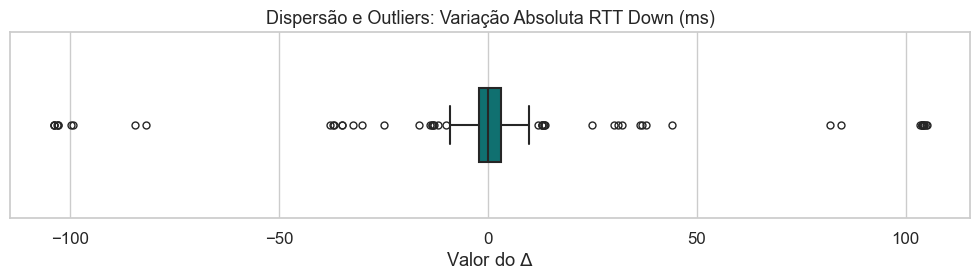

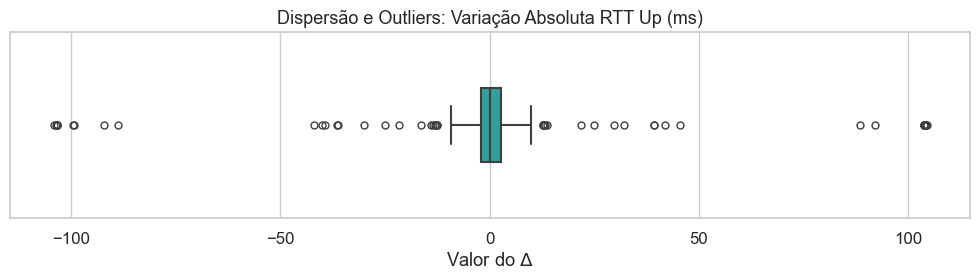

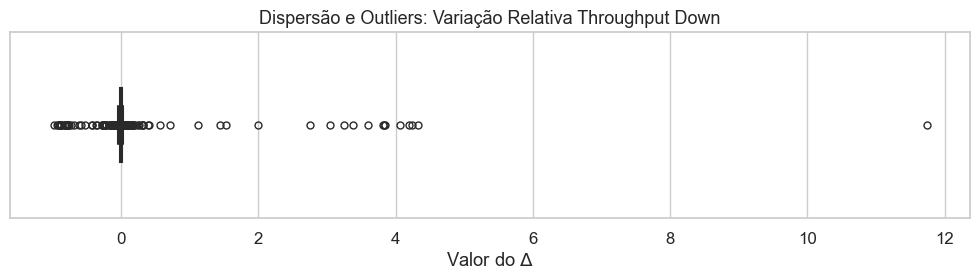

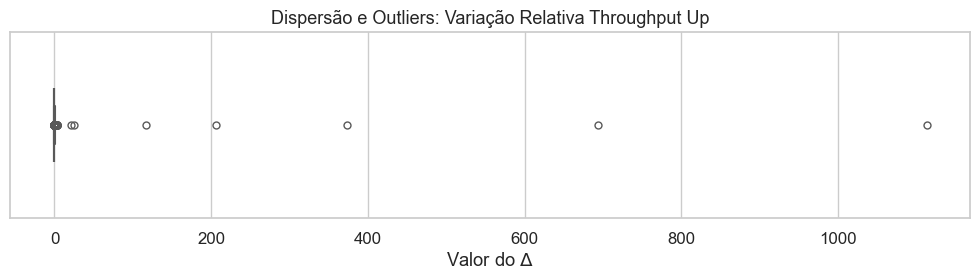

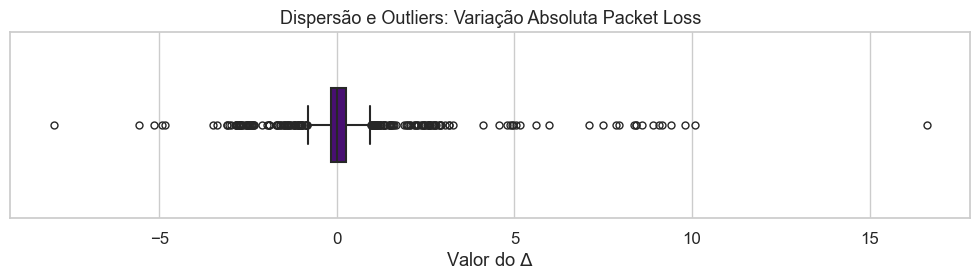

In [44]:
# Configuração das métricas para a plotagem individual dos boxplots
metrics_to_plot_box = [
    ('d_rtt_down', 'Variação Absoluta RTT Down (ms)', 'teal'),
    ('d_rtt_up', 'Variação Absoluta RTT Up (ms)', 'lightseagreen'),
    ('d_tp_down', 'Variação Relativa Throughput Down', 'darkred'),
    ('d_tp_up', 'Variação Relativa Throughput Up', 'indianred'),
    ('d_pl', 'Variação Absoluta Packet Loss', 'indigo')
]

# Geração de uma figura independente para cada métrica
for col, label, color in metrics_to_plot_box:
    if col in df_ana.columns:
        plt.figure(figsize=(10, 3))
        
        # Criação do boxplot horizontal
        sns.boxplot(
            x=df_ana[col], 
            color=color, 
            width=0.4, 
            fliersize=5, 
            linewidth=1.5
        )
        
        plt.title(f"Dispersão e Outliers: {label}", fontsize=13)
        plt.xlabel("Valor do $\\Delta$")
        
        # Ajuste de layout para evitar cortes
        plt.tight_layout()
        plt.show()

## 1.6 Análise de Assimetria e Impacto da Perda de Pacotes

Esta seção utiliza gráficos de dispersão para identificar correlações entre as métricas e validar as assinaturas de rede. A análise foca na relação entre latência (RTT) e vazão (TP) em ambos os sentidos, além do impacto da perda de pacotes ($\Delta PL$) como indicador de severidade.

### Justificativa Técnica para a Classificação

A disposição dos eventos nos quadrantes dos gráficos orienta a separação dos clusters pelo GMM:

* **Assinatura de Congestionamento:** Identificada pela relação inversa entre RTT e Throughput (aumento de latência com queda de vazão). A presença de correlação positiva entre $\Delta RTT$ e $\Delta PL$ confirma o transbordo de buffers (*bufferbloat*), essencial para caracterizar o cluster de congestionamento severo.
* **Assimetria de Direcionalidade:** A comparação entre os sentidos de Download e Upload revela se os eventos de mudança são simétricos ou se o gargalo está concentrado em apenas uma direção. Isso justifica tratar as direções como dimensões independentes no modelo.
* **Diferenciação de Eventos Isolados:** O mapeamento via *Synchronization Score* ($S_{e}$) nos gráficos permite visualizar se eventos com alta sincronização ocupam regiões específicas do espaço de características, facilitando a convergência dos componentes do GMM.

Esta análise visual confirma se as variáveis possuem poder discriminatório para separar eventos de natureza distinta, como mudanças de rota (variação de RTT com baixa perda) e saturação de link (variação conjunta de múltiplas métricas).

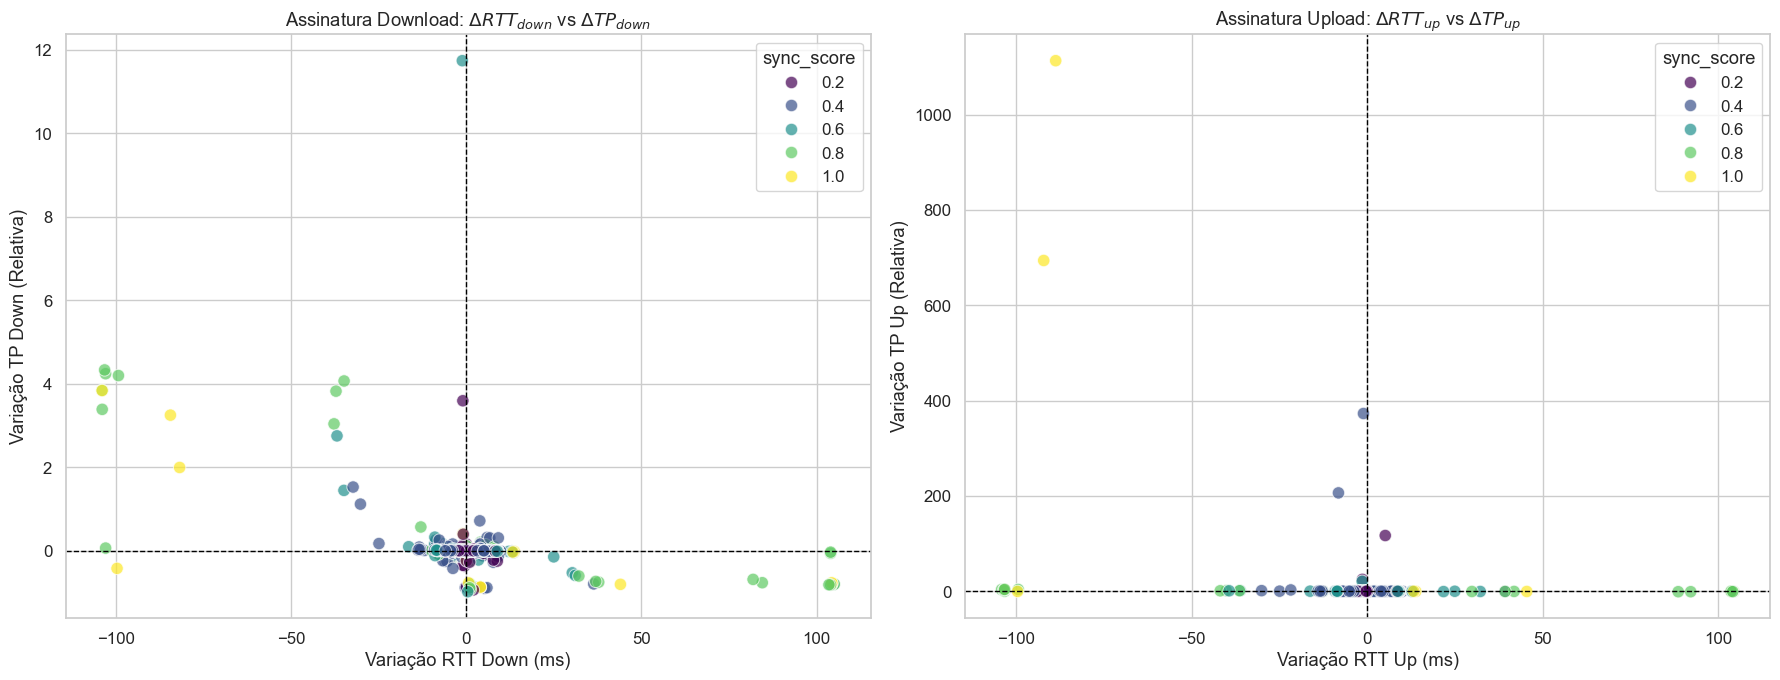

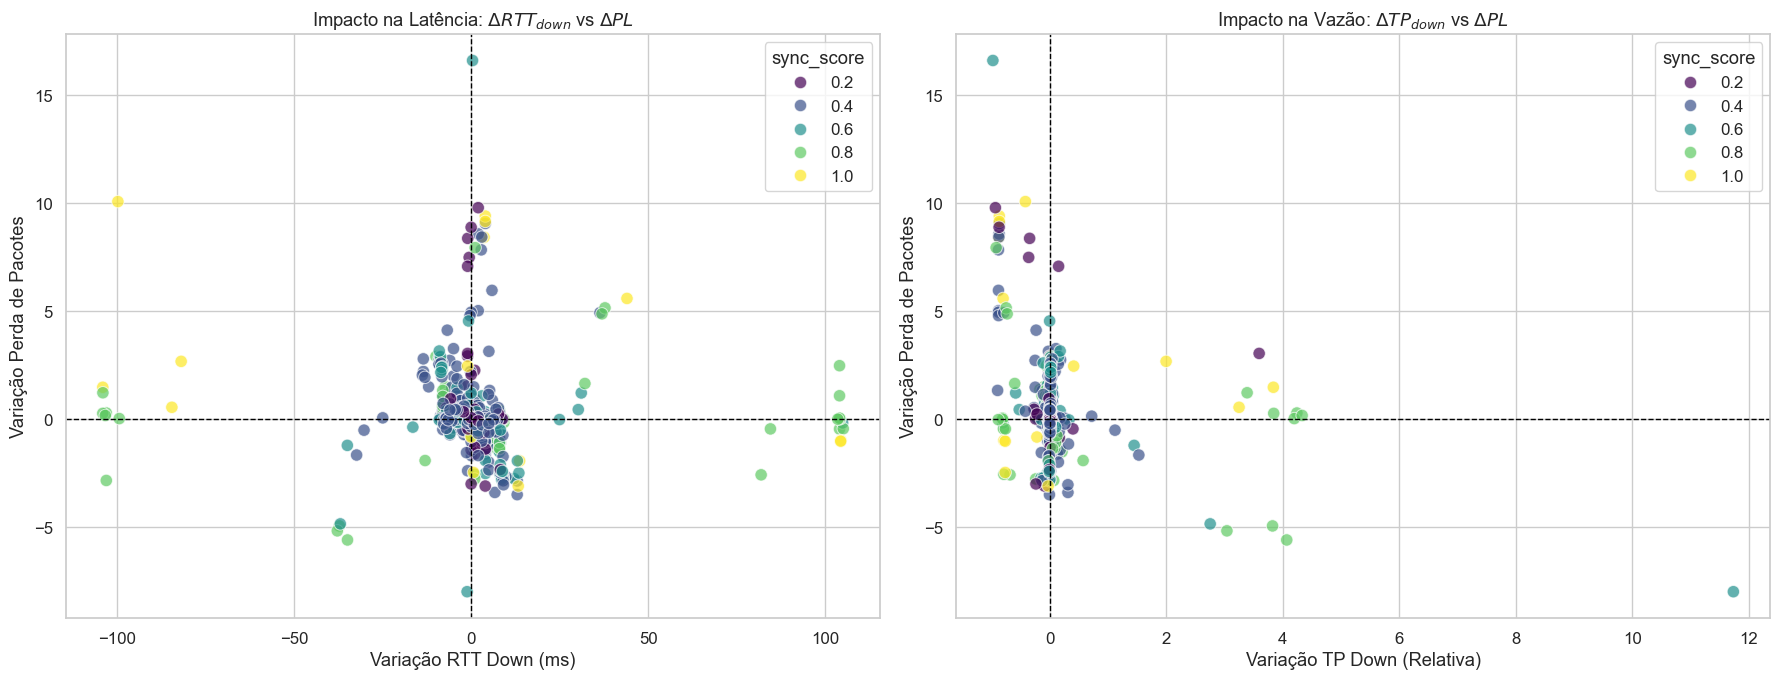

In [45]:
# --- Comparação de Assinaturas: Download vs Upload ---

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Download: RTT vs Throughput
sns.scatterplot(data=df_ana, x='d_rtt_down', y='d_tp_down', 
                hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[0])
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set_title(r"Assinatura Download: $\Delta RTT_{down}$ vs $\Delta TP_{down}$")
axes[0].set_xlabel("Variação RTT Down (ms)")
axes[0].set_ylabel("Variação TP Down (Relativa)")
# axes[0].set_xlim(-50, 50)
# axes[0].set_ylim(-1, 1)

# 2. Upload: RTT vs Throughput
sns.scatterplot(data=df_ana, x='d_rtt_up', y='d_tp_up', 
                hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[1])
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_title(r"Assinatura Upload: $\Delta RTT_{up}$ vs $\Delta TP_{up}$")
axes[1].set_xlabel("Variação RTT Up (ms)")
axes[1].set_ylabel("Variação TP Up (Relativa)")

plt.tight_layout()
plt.show()

# --- Análise do Impacto da Perda de Pacotes ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Packet Loss vs RTT Down
sns.scatterplot(data=df_ana, x='d_rtt_down', y='d_pl', 
                hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[0])
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set_title(r"Impacto na Latência: $\Delta RTT_{down}$ vs $\Delta PL$")
axes[0].set_xlabel("Variação RTT Down (ms)")
axes[0].set_ylabel("Variação Perda de Pacotes")

# 2. Packet Loss vs Throughput Down
sns.scatterplot(data=df_ana, x='d_tp_down', y='d_pl', 
                hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[1])
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_title(r"Impacto na Vazão: $\Delta TP_{down}$ vs $\Delta PL$")
axes[1].set_xlabel("Variação TP Down (Relativa)")
axes[1].set_ylabel("Variação Perda de Pacotes")

plt.tight_layout()
plt.show()

# 2. Clusterização de Eventos (GMM)

Esta seção apresenta a aplicação do Modelo de Mistura Gaussiana (GMM) para identificar padrões latentes de comportamento na rede. O objetivo é agrupar as transições detectadas em categorias semânticas com base na correlação multivariada das métricas.

## 2.1 Seleção do Número de Componentes ($K$)

Para determinar o número ideal de clusters, avaliamos o desempenho do modelo variando o parâmetro $K$. A escolha baseia-se no equilíbrio entre o ajuste aos dados e a complexidade do modelo, utilizando critérios de informação estatística:

* **AIC/BIC:** Indicadores que penalizam modelos com excesso de parâmetros. Valores menores sugerem um melhor compromisso entre ajuste e simplicidade do modelo.
* **Log-Likelihood (LL):** Mede quão bem os parâmetros do modelo explicam os dados. Aumentos no LL indicam que o modelo descreve melhor a amostra.
* **Delta_BIC/Delta_LL:** Quantificam o ganho marginal ao adicionar um novo cluster. Delta_BIC negativo indica ganho de qualidade e Delta_LL positivo indica melhor ajuste aos dados.

> **Nota técnica:** A escolha do $K$ final busca evitar a fragmentação excessiva dos dados, priorizando um número de clusters que possua significado físico (ex: separação clara entre Congestionamento e Mudança de Rota).

In [46]:
# Caminho dos relatórios baseado no cenário atual
path = os.path.join("clusters", SCENARIO)

if not os.path.exists(path):
    print(f"Erro: Pasta {path} não encontrada.")
else:
    data = []
    
    # Regex para capturar K do nome do arquivo e os valores dentro do TXT
    # Utiliza as variáveis globais METHOD (vwcd), REF_METRIC (full) e THRESHOLD
    file_pattern = rf"clusters_K(\d+)_features_{METHOD}_{REF_METRIC}_{THRESHOLD}\.txt"    

    for file in os.listdir(path):
        match = re.match(file_pattern, file)
        if match:
            k_val = int(match.group(1))
            full_path = os.path.join(path, file)
            
            with open(full_path, 'r') as f:
                content = f.read()
                
                # Extração via Regex dos valores numéricos
                aic = re.search(r"AIC.*: ([\d\.-]+)", content)
                bic = re.search(r"BIC.*: ([\d\.-]+)", content)
                ll  = re.search(r"Log-Likelihood: ([\d\.-]+)", content)
                events = re.search(r"Total de Eventos: (\d+)", content)
                
                if aic and bic and ll:
                    data.append({
                        'K': k_val,
                        'Events': int(events.group(1)) if events else 0,
                        'Log-Likelihood': float(ll.group(1)),
                        'AIC': float(aic.group(1)),
                        'BIC': float(bic.group(1))
                    })

    if not data:
        print("Nenhum relatório encontrado para os parâmetros fornecidos.")
    else:
        # Criar DataFrame e ordenar por K
        df_comp = pd.DataFrame(data).sort_values('K').reset_index(drop=True)
        
        # Calcular a diferença (Delta) entre o K atual e o anterior
        df_comp['Delta_BIC'] = df_comp['BIC'].diff()
        df_comp['Delta_LL']  = df_comp['Log-Likelihood'].diff()

        # Colocar 0 se o Delta for NaN (primeira linha)
        df_comp['Delta_BIC'] = df_comp['Delta_BIC'].fillna(0)
        df_comp['Delta_LL'] = df_comp['Delta_LL'].fillna(0)

        print(f"\nCOMPARAÇÃO DE MODELOS - CENÁRIO: {SCENARIO}")
        print(f"Métrica: {REF_METRIC} | Threshold: {THRESHOLD}")
        print("=" * 85)
        print(df_comp.to_string(index=False))
        print("=" * 85)


COMPARAÇÃO DE MODELOS - CENÁRIO: NDT_NOV_ABR
Métrica: rtt_down | Threshold: 0.95
 K  Events  Log-Likelihood       AIC       BIC  Delta_BIC  Delta_LL
 2     869        -2273.43   4628.86   4824.32       0.00      0.00
 3     869         1731.79  -3339.58  -3044.01   -7868.33   4005.22
 4     869         1914.30  -3662.60  -3266.91    -222.90    182.51
 5     869         5216.00 -10223.99  -9728.19   -6461.28   3301.70
 6     869         5915.35 -11580.70 -10984.78   -1256.59    699.35
 7     869         6134.89 -11977.78 -11281.75    -296.97    219.54
 8     869         6131.70 -11929.41 -11133.26     148.49     -3.19
 9     869         6148.20 -11920.39 -11024.13     109.13     16.50
10     869         6609.01 -12800.02 -11803.64    -779.51    460.81


## 2.2 Análise dos Parâmetros e Assinaturas dos Clusters

Com base no valor de $K$ selecionado (aquele com os maiores deltas de BIC e LL em relação ao anterior), as propriedades estatísticas de cada componente são analisadas para identificar as "assinaturas" de rede. Esta etapa utiliza as métricas de ajuste global e a distribuição de eventos para validar a coerência do modelo.

### Métricas de Ajuste do Modelo
* **AIC:** {valor}
* **BIC:** {valor}
* **Log-Likelihood:** {valor}

### Caracterização dos Clusters

A interpretação dos resultados fundamenta-se nos indicadores de comportamento e densidade extraídos do GMM:

1. **Assinaturas Médias (Visualização por Heatmap):** O centro de cada cluster (médias na escala original) define o perfil da transição de rede. O mapa de calor facilita a identificação de padrões coordenados, como o aumento simultâneo de latência e queda de vazão, permitindo correlacionar os agrupamentos a fenômenos como congestionamento ou mudanças de rota.
2. **Volumetria e Representatividade:** A contagem e o percentual de eventos em cada cluster revelam a dominância de certos comportamentos. Agrupamentos com alta densidade indicam o estado típico de operação ou falhas recorrentes, enquanto componentes com baixíssima contagem sinalizam eventos atípicos ou instabilidades isoladas pelo modelo.
3. **Fundamentação Multivariada:** Embora a análise priorize a visualização das médias, a separação dos clusters pelo GMM é sustentada pelas matrizes de covariância calculadas internamente. Isso garante que o agrupamento reflita a dependência estatística entre as variáveis, isolando perfis onde as métricas variam de forma sistêmica.

Esta análise permite verificar se o algoritmo foi capaz de distinguir estados de rede estáveis de anomalias severas, transformando as métricas processadas em categorias funcionais de diagnóstico.

RELATÓRIO DE AJUSTE GLOBAL - K=5
---------------------------------------------
AIC (Akaike Information Criterion): -10223.99
BIC (Bayesian Information Criterion): -9728.19
Log-Likelihood: 5216.00
---------------------------------------------


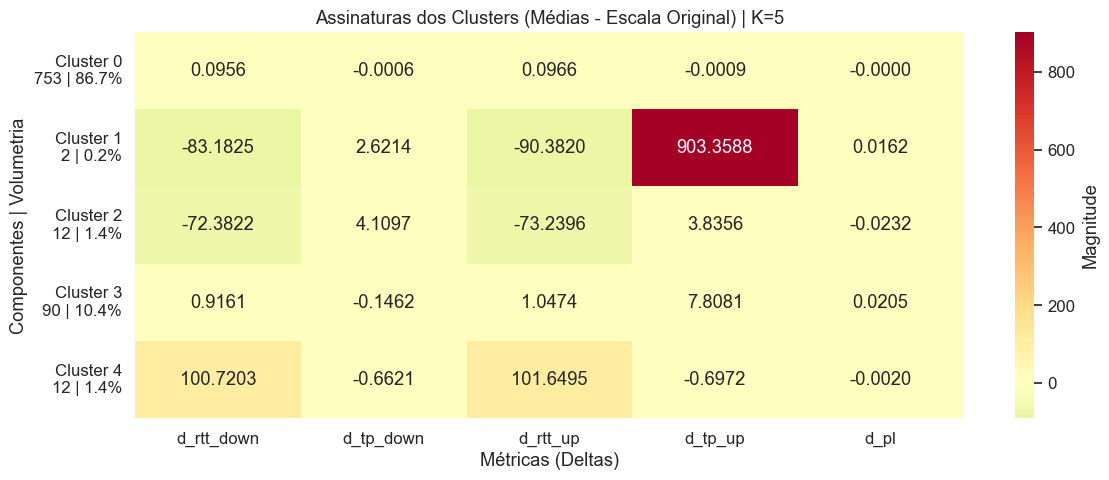


ANÁLISE DE COVARIÂNCIA (ESTRUTURA DE CORRELAÇÃO)
---------------------------------------------


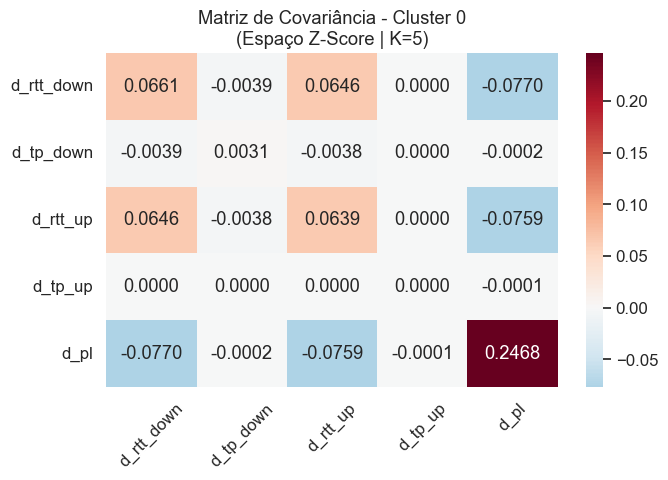

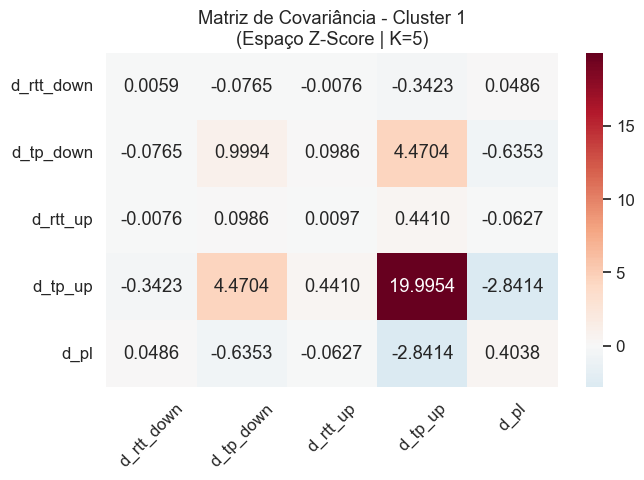

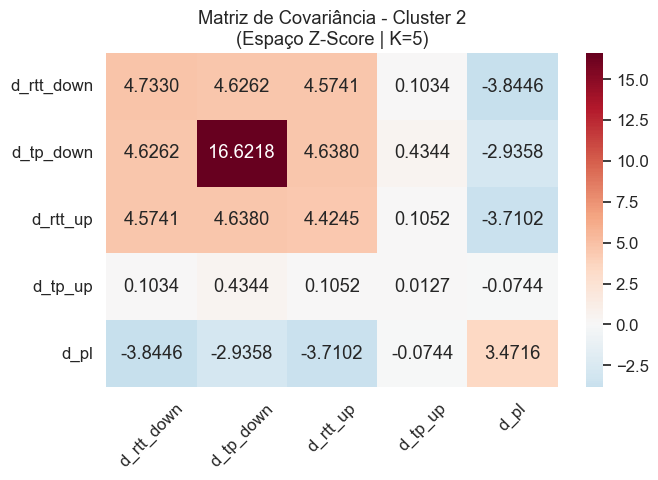

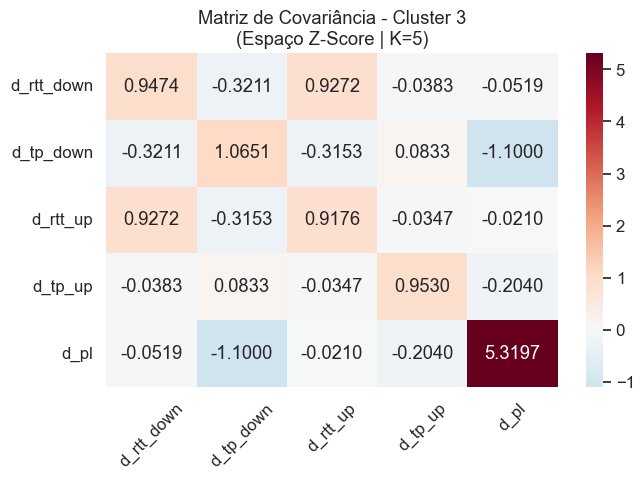

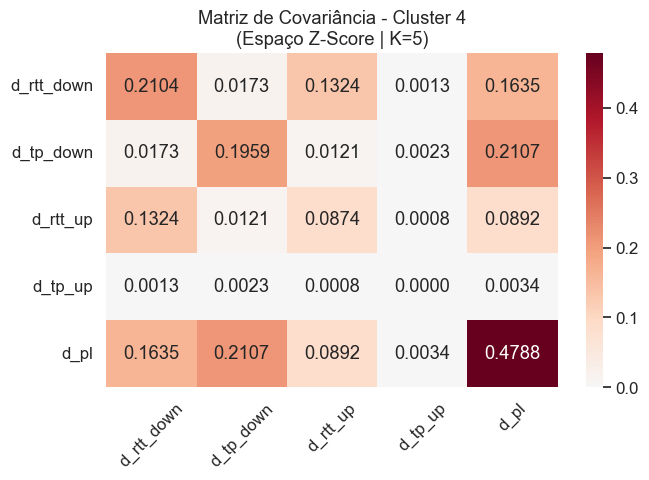

In [47]:
# --- Configuração da Análise ---
K_ANALISE = 5
k_str = str(K_ANALISE).zfill(2)
file_name = f"clusters_K{k_str}_features_{METHOD}_{REF_METRIC}_{THRESHOLD}.txt"
full_path = os.path.join("clusters", SCENARIO, file_name)

if not os.path.exists(full_path):
    print(f"Erro: Arquivo não encontrado em {full_path}")
else:
    with open(full_path, 'r') as f:
        content = f.read()

    # --- 1. RELATÓRIO DE AJUSTE GLOBAL ---
    print(f"RELATÓRIO DE AJUSTE GLOBAL - K={K_ANALISE}")
    print("-" * 45)
    for pattern in [r"AIC.*: ([\d\.-]+)", r"BIC.*: ([\d\.-]+)", r"Log-Likelihood: ([\d\.-]+)"]:
        match = re.search(pattern, content)
        if match:
            print(match.group(0))
    print("-" * 45)

    # --- 2. PROCESSAMENTO DOS CLUSTERS (MÉDIAS E VOLUMETRIA) ---
    cluster_data = []
    volumetry_labels = {}
    cluster_blocks = re.split(r"(Cluster \d+:)", content)
    metrics_list = ['d_rtt_down', 'd_tp_down', 'd_rtt_up', 'd_tp_up', 'd_pl']

    for i in range(1, len(cluster_blocks), 2):
        c_id = cluster_blocks[i].replace(":", "").strip()
        body = cluster_blocks[i+1]
        
        # Extração da Volumetria para os labels do eixo Y
        count_match = re.search(r"Quantidade de Eventos:\s+(\d+)\s+\(([\d\.]+%)\)", body)
        if count_match:
            volumetry_labels[c_id] = f"{c_id}\n{count_match.group(1)} | {count_match.group(2)}"
        
        # Extração das Médias
        means = {}
        for metric in metrics_list:
            m_match = re.search(rf"{metric}:\s+([\d\.-]+)", body)
            if m_match:
                means[metric] = float(m_match.group(1))
        
        if means:
            means['Cluster'] = c_id
            cluster_data.append(means)

    # Plotagem do Heatmap de Médias
    df_heatmap = pd.DataFrame(cluster_data).set_index('Cluster')
    df_heatmap.index = [volumetry_labels.get(idx, idx) for idx in df_heatmap.index]

    plt.figure(figsize=(12, 5))
    sns.heatmap(df_heatmap, annot=True, cmap='RdYlGn_r', center=0, fmt=".4f", cbar_kws={'label': 'Magnitude'})
    plt.title(f"Assinaturas dos Clusters (Médias - Escala Original) | K={K_ANALISE}")
    plt.xlabel("Métricas (Deltas)")
    plt.ylabel("Componentes | Volumetria")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # --- 3. ANÁLISE DE COVARIÂNCIA POR CLUSTER ---
    print("\nANÁLISE DE COVARIÂNCIA (ESTRUTURA DE CORRELAÇÃO)")
    print("-" * 45)
    
    for i in range(1, len(cluster_blocks), 2):
        c_id = cluster_blocks[i].replace(":", "").strip()
        body = cluster_blocks[i+1]

        # Busca a matriz entre [[ e ]]
        matrix_match = re.search(r"Matriz de Covariancia .*?:\n\s*\[\[(.*?)\]\]", body, re.DOTALL)

        if matrix_match:
            matrix_str = matrix_match.group(1)
            clean_rows = []
            for row in matrix_str.split('\n'):
                row_stripped = row.replace('[', '').replace(']', '').strip()
                if row_stripped:
                    clean_rows.append([float(val) for val in row_stripped.split()])

            cov_matrix = np.array(clean_rows)

            # Plotagem do Heatmap da Matriz de Covariância
            plt.figure(figsize=(7, 5))
            sns.heatmap(cov_matrix, annot=True, fmt=".4f", cmap='RdBu_r', center=0,
                        xticklabels=metrics_list, yticklabels=metrics_list)
            
            plt.title(f"Matriz de Covariância - {c_id}\n(Espaço Z-Score | K={K_ANALISE})")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()